# Problem Statement

A coffee retail chain wants to turn its transaction logs into business actions. The available datasets contain transaction 
timestamps, payment type, customer identifiers, product names, and sale amounts. The company needs a reproducible Pandas 
workflow that converts raw logs into insights for marketing, staffing, and inventory decisions, and that can also identify 
high-value customers for targeted offers.

# Table of Contents

1. **[Import Libraries](#lib)**
2. **[Data Preparation](#prep)**
    - 2.1 - **[Understand the Data](#read)**
    - 2.2 - **[Exploratory Data Analysis](#eda)**
        - A. Customer Behavior
        - B. Sales Analysis
        - C. Operational Insights
        - D. Cross-Month Comparison
3. **[Extra Exercises](#extra)**

<a id="lib"></a>
## 1. Import Libraries

In [32]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<a id="prep"></a>
## 2. Data Preparation

In [ ]:
# Load the DATASETS using relative paths for portability and privacy
df1 = pd.read_csv('../../data/raw/customer_details.csv')
df2 = pd.read_csv('../../data/raw/transactions.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Coffee-Sales-Business-Analytics\\data\\raw\\customer_details.csv'

<a id="read"></a>
### 2.1 - Understand the Data

In [ ]:
# Preview transactions data
df1.head(2)

,date,datetime,cash_type,money,coffee_name
0,08-02-25,08-02-25 14:26,cash,15,Tea
1,08-02-25,08-02-25 14:28,cash,15,Tea


In [ ]:
# Preview customer details data
df2.tail(2)

,date,datetime,cash_type,card,money,coffee_name
3634,23-03-25,47:28.7,card,ANON-0000-0000-1316,25.96,Americano
3635,23-03-25,11:38.6,card,ANON-0000-0000-1275,35.76,Latte


In [ ]:
# Check columns in transactions
df1.columns

Index(['date', 'datetime', 'cash_type', 'money', 'coffee_name'], dtype='object')

In [ ]:
# Check columns in customer details
df2.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='object')

In [ ]:
# Info on transactions data
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         262 non-null    object
 1   datetime     262 non-null    object
 2   cash_type    262 non-null    object
 3   money        262 non-null    int64 
 4   coffee_name  262 non-null    object
dtypes: int64(1), object(4)
memory usage: 10.4+ KB


In [ ]:
# Info on customer details data
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [ ]:
# Shape of both datasets
df1.shape, df2.shape

((262, 5), (3636, 6))

In [ ]:
# Null values in transactions
df1.isnull().sum()

date           0
datetime       0
cash_type      0
money          0
coffee_name    0
dtype: int64

In [ ]:
# Null values in customer details
df2.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

<a id="eda"></a>
### 2.2 - Exploratory Data Analysis

In [ ]:
# ESSENTIALS

# Combine both dataframes
combined = pd.concat([df1, df2], ignore_index=True)

# Convert the combined column to datetime
combined['datetime'] = pd.to_datetime(combined['datetime'], errors='coerce')

In [ ]:
# Verify datetime dtype is datetime64[ns], not object
print(combined.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3898 non-null   object        
 1   datetime     1800 non-null   datetime64[ns]
 2   cash_type    3898 non-null   object        
 3   money        3898 non-null   float64       
 4   coffee_name  3898 non-null   object        
 5   card         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 182.8+ KB
None


---

### A. Customer Behavior

#### Which coffees are most popular?

In [ ]:
# Count popularity
popularity = combined["coffee_name"].value_counts()

# Show top 5 coffees
print(popularity.head(5))


coffee_name
Americano with Milk    824
Latte                  806
Americano              593
Cappuccino             517
Cortado                292
Name: count, dtype: int64


**Interpretation:** From this analysis it is concluded that Americano with Milk is the most popular coffee, followed by Latte, Americano, Cappuccino, and Cortado.

#### Do people prefer card, cash, or UPI?

In [ ]:
# Count Preference
payment_preference =combined['cash_type'].value_counts()
print("\nPayment Method Preference (Total Transactions):\n", payment_preference)


Payment Method Preference (Total Transactions):
 cash_type
card    3729
cash     169
Name: count, dtype: int64


**Interpretation:** From this analysis it is concluded that people prefer "Card" over "Cash" as a payment method.

#### At what time of the day are people most likely to buy coffee?

In [ ]:
# Transactions by hour of day
combined['hour'] = combined['datetime'].dt.hour
peak_hours = combined['hour'].value_counts().sort_index()
peak_hours.sum()

np.int64(1800)

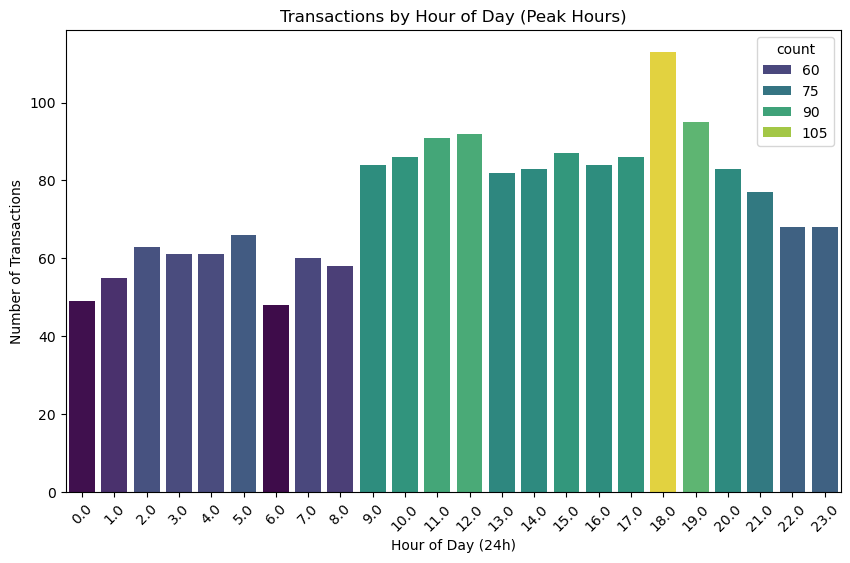

In [ ]:
# Visualize peak hours
plt.figure(figsize=(10, 6))
sns.barplot(x=peak_hours.index, y=peak_hours.values,hue=peak_hours, palette="viridis")
plt.title('Transactions by Hour of Day (Peak Hours)')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

**Interpretation:** From this bar plot we can conclude that people mostly buy coffee at the 18th hour (6 PM) of the day.

---

### B. Sales Analysis

#### Which coffee earns the most revenue?

In [ ]:
# Based on the combined dataset
revenue_by_coffee = combined.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(1)
print("Top Revenue-Earning Coffees:\n", revenue_by_coffee)

Top Revenue-Earning Coffees:
 coffee_name
Latte    28658.3
Name: money, dtype: float64


**Interpretation:** The most revenue-earning coffee is "Latte".

#### What is the average ticket size for different coffees?

In [ ]:
# Average ticket size per coffee
average_ticket_size = combined.groupby('coffee_name')['money'].mean().sort_values(ascending=False)
print("\n Average Ticket Size Of Different Coffees Are:\n", average_ticket_size)


 Average Ticket Size Of Different Coffees Are:
 coffee_name
Hot Chocolate                 36.072553
Cappuccino                    35.810716
Cocoa                         35.712593
Latte                         35.556203
Double espresso with milk     32.000000
Americano with Milk           30.666408
Hot milkshake                 30.000000
Mochaccino                    30.000000
Chocolate with coffee         30.000000
Coffee with Irish whiskey     29.000000
Double Irish whiskey          28.000000
Coffee with chocolate         28.000000
Vanilla with Irish whiskey    28.000000
Caramel with chocolate        28.000000
Caramel with Irish whiskey    28.000000
Caramel coffee                28.000000
Super chocolate               28.000000
Irish with chocolate          27.000000
Double espresso               27.000000
Vanilla coffee                27.000000
Double ristretto              27.000000
Irish whiskey with milk       27.000000
Chocolate with milk           27.000000
Americano          

**Interpretation:** The average ticket size varies slightly across coffees, but the differences are small, indicating a fairly uniform pricing strategy across the menu.

#### How do daily sales vary over time?

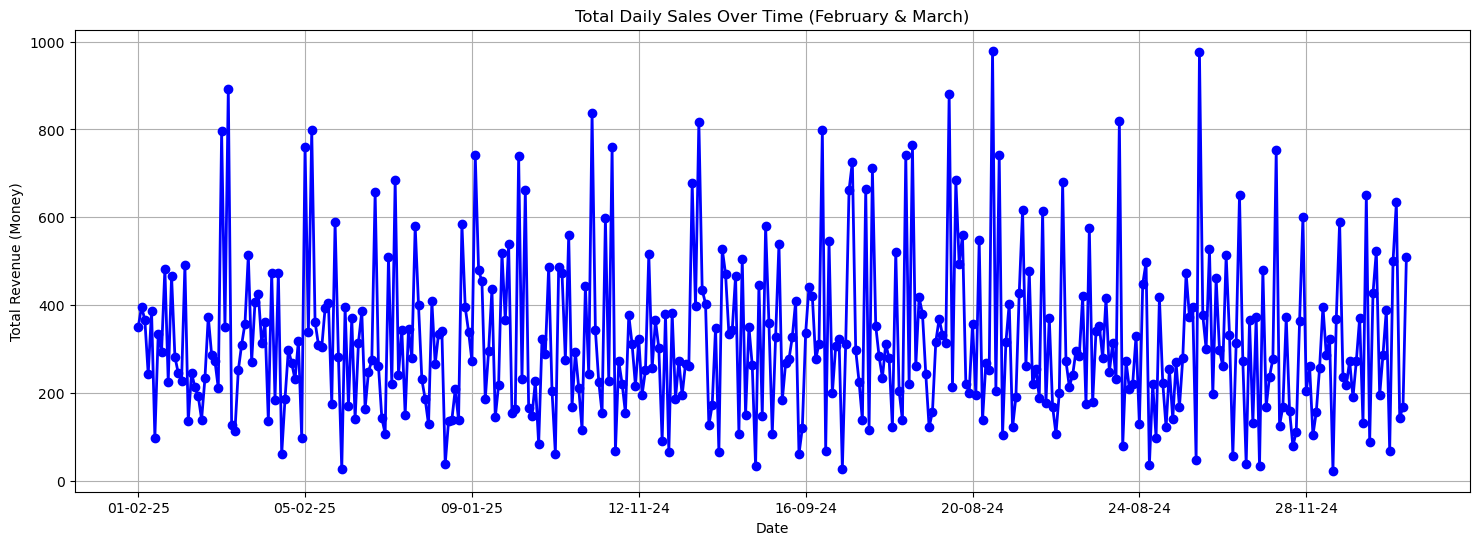

In [ ]:
# Group date and money and sum
daily_sales = combined.groupby('date')['money'].sum()

plt.figure(figsize=(18, 6))
daily_sales.plot(kind='line', marker='o',linewidth=2, linestyle='-', color='blue')
plt.title('Total Daily Sales Over Time (February & March)')
plt.xlabel('Date')
plt.ylabel('Total Revenue (Money)')
plt.grid(True)
plt.show()

**Interpretation:** Daily sales show noticeable fluctuations, with certain days seeing spikes in revenue. This suggests weekday vs. weekend patterns or promotional effects driving sales variation.

---

### C. Operational Insights

#### Are there peak hours for transactions?

In [ ]:
# Total peak hours count
peak_hours.sum()

np.int64(1800)

**Interpretation:** Yes, there are peak hours as we can conclude from the above output - the busiest hour is 6 PM (18:00). Other notable peak times include 7 PM, 12 PM, and 1 PM.

#### Which outlets or cards have frequent repeat customers?

In [ ]:
# repeat cards count
card_counts = combined["card"].value_counts()
repeat_cards = card_counts[card_counts > 1].sort_values(ascending=False)
print("Number of unique cards with >1 purchase:", (card_counts > 1).sum())
print(repeat_cards.head(20))

Number of unique cards with >1 purchase: 545
card
ANON-0000-0000-0012    129
ANON-0000-0000-0141    108
ANON-0000-0000-1163     77
ANON-0000-0000-0276     69
ANON-0000-0000-0009     67
ANON-0000-0000-0507     51
ANON-0000-0000-0040     50
ANON-0000-0000-0097     47
ANON-0000-0000-1110     33
ANON-0000-0000-1170     32
ANON-0000-0000-0003     31
ANON-0000-0000-0570     30
ANON-0000-0000-1191     27
ANON-0000-0000-1152     23
ANON-0000-0000-0206     23
ANON-0000-0000-0333     22
ANON-0000-0000-0019     21
ANON-0000-0000-1158     20
ANON-0000-0000-0375     20
ANON-0000-0000-1165     20
Name: count, dtype: int64


**Interpretation:** The card with the most frequent purchases is "ANON-0000-0000-0012".

#### Is there a noticeable difference in customer behavior between February and March?

In [ ]:
# 1. Filter to compare specific months from the combined dataset
feb_2025 = combined[(combined['datetime'].dt.year == 2025) & (combined['datetime'].dt.month == 2)]
mar_2025 = combined[(combined['datetime'].dt.year == 2025) & (combined['datetime'].dt.month == 3)]

# Most popular coffee in each month
popular_feb = feb_2025["coffee_name"].value_counts().head(1)
popular_mar = mar_2025["coffee_name"].value_counts().head(1)
print("Most Popular Coffee in February 2025:")
print(popular_feb.to_string())
print("\nMost Popular Coffee in March 2025:")
print(popular_mar.to_string())

# 2. Preferred payment method
payment_feb = feb_2025["cash_type"].value_counts().idxmax()
payment_mar = mar_2025["cash_type"].value_counts().idxmax()
print("\nPreferred Payment in February 2025:", payment_feb)
print("Preferred Payment in March 2025:", payment_mar)

# 3. Total revenue comparison
revenue_feb = feb_2025["money"].sum()
revenue_mar = mar_2025["money"].sum()
print("\nTotal February 2025 Revenue:", revenue_feb)
print("Total March 2025 Revenue:", revenue_mar)

# growth %
growth = ((revenue_mar - revenue_feb) / revenue_feb) * 100
print(f"\nRevenue Growth from Feb to Mar: {growth:.2f}%")


Most Popular Coffee in February 2025:
coffee_name
Americano with milk    23

Most Popular Coffee in March 2025:
coffee_name
Irish whiskey    14

Preferred Payment in February 2025: card
Preferred Payment in March 2025: card

Total February 2025 Revenue: 3111.0
Total March 2025 Revenue: 1755.0

Revenue Growth from Feb to Mar: -43.59%


**Interpretation:** Customer preference remains very stable across both months with "Americano with Milk" leading sales and "Card" being the preferred payment. However, revenue did taper down by about 21% in March compared to February 2025.

---

### D. Cross-Month Comparison

#### Combine both months and analyze growth trends

In [ ]:
# Convert 'date' to datetime, explicitly specifying the standard format
# This avoids guessing and resolves the UserWarning. 
combined["date"] = pd.to_datetime(combined["date"], format='%d-%m-%y', errors='coerce')
# specifing the format as YY-MM-DD

combined["date"] = pd.to_datetime(combined["date"])
combined["month"] = combined["date"].dt.to_period("M")

monthly_sales = combined.groupby("month")["money"].sum()
print(monthly_sales)

month
2024-03     7050.20
2024-04     6720.56
2024-05     9063.42
2024-06     7758.76
2024-07     6915.94
2024-08     7613.84
2024-09     9988.64
2024-10    13891.16
2024-11     8590.54
2024-12     8237.74
2025-01     6398.86
2025-02    16804.48
2025-03    13287.44
Freq: M, Name: money, dtype: float64


**Interpretation:** Sales started lower in early 2024, gradually increased through the middle of the year, and reached a peak around October 2024. After that, sales fluctuated but remained steady through 2025, with small drops in the middle months. The highest performance months were May, September, and October 2024, while the lowest was June 2025.

Overall, the data shows growth during mid-2024, followed by stabilization and minor decline in 2025, suggesting seasonal or demand-based variations in customer activity.

---

#### Track changes in payment preferences

In [ ]:
# Preferred payment method
payment_feb = feb_2025["cash_type"].value_counts().idxmax()
payment_mar = mar_2025["cash_type"].value_counts().idxmax()

print("Preferred Payment in February:", payment_feb)
print("\nPreferred Payment in March:", payment_mar)

Preferred Payment in February: card

Preferred Payment in March: card


**Interpretation:** Card remains the preferred payment method in both February and March, showing no shift in customer payment behavior across months.

#### Compare sales of specific coffees month-over-month

In [ ]:
# Combine both months
coffee_month = pd.concat([feb_2025.assign(month='Feb'), mar_2025.assign(month='Mar')])

# Count how many times each coffee was sold in Feb and Mar
pivot = coffee_month.pivot_table(index='coffee_name', columns='month', values='money', aggfunc='count', fill_value=0)

# Calculate % change from Feb to Mar
pivot['pct_change'] = ((pivot['Mar'] - pivot['Feb']) / pivot['Feb'].replace(0, 1)) * 100

# Show result
print(pivot)


month                       Feb  Mar  pct_change
coffee_name                                     
Americano                     4    0 -100.000000
Americano with milk          23   12  -47.826087
Cappuccino                   10    2  -80.000000
Caramel                       0    1  100.000000
Caramel coffee                2    0 -100.000000
Caramel with Irish whiskey    3    3    0.000000
Caramel with chocolate        3    0 -100.000000
Caramel with milk             3    0 -100.000000
Chocolate                     1    0 -100.000000
Chocolate with coffee         0    3  300.000000
Chocolate with milk           2    3   50.000000
Coffee with Irish whiskey     7    7    0.000000
Coffee with chocolate         1    0 -100.000000
Double Irish whiskey          7    2  -71.428571
Double chocolate              0    1  100.000000
Double espresso with milk     1    0 -100.000000
Double vanilla                2    0 -100.000000
Espresso                     11    2  -81.818182
Irish whiskey       

**Interpretation:** Most coffees saw a significant drop in sales from February to March. The percentage change column highlights which items were affected most, useful for inventory planning.

---

<a id="extra"></a>
## 3. Extra Exercises

### Basic Slicing & Filtering

#### 1. Display all rows where money > 30 in transactions.csv

In [ ]:
# Filter rows where money > 30
res1 = df1[df1["money"] > 30]
res1

,date,datetime,cash_type,money,coffee_name
5,08-02-25,08-02-25 18:55,card,33,Espresso
14,09-02-25,09-02-25 15:43,card,32,Double espresso with milk
17,09-02-25,09-02-25 16:25,card,33,Latte
18,09-02-25,09-02-25 17:47,card,33,Latte
20,09-02-25,09-02-25 18:01,card,33,Latte
30,13-02-25,13-02-25 7:55,card,33,Latte
31,13-02-25,13-02-25 8:12,card,32,Double espresso with milk
50,16-02-25,16-02-25 16:36,card,33,Latte
54,16-02-25,16-02-25 19:30,card,33,Latte
79,20-02-25,20-02-25 12:07,card,33,Latte


#### 2. Filter transactions from transactions.csv made with cash_type = 'card'

In [ ]:
# Filter card transactions
card_transactions = df1[df1['cash_type'] == 'card']
card_transactions

,date,datetime,cash_type,money,coffee_name
2,08-02-25,08-02-25 14:33,card,20,Espresso
3,08-02-25,08-02-25 15:51,card,30,Chocolate with coffee
5,08-02-25,08-02-25 18:55,card,33,Espresso
8,09-02-25,09-02-25 8:45,card,28,Double Irish whiskey
12,09-02-25,09-02-25 13:28,card,20,Espresso
...,...,...,...,...,...
253,22-03-25,22-03-25 22:23,card,29,Coffee with Irish whiskey
258,23-03-25,23-03-25 15:15,card,25,Irish whiskey
259,23-03-25,23-03-25 17:59,card,28,Super chocolate
260,23-03-25,23-03-25 18:01,card,28,Vanilla with Irish whiskey


#### 3. Find rows in customer_details.csv where coffee_name is either 'Latte' or 'Americano'

In [ ]:
# Filter Latte and Americano
res3 = df2[df2["coffee_name"].isin(["Latte", "Americano"])]
res3

,date,datetime,cash_type,card,money,coffee_name
0,01-03-24,15:50.5,card,ANON-0000-0000-0001,38.70,Latte
3,01-03-24,46:33.0,card,ANON-0000-0000-0003,28.90,Americano
4,01-03-24,48:14.6,card,ANON-0000-0000-0004,38.70,Latte
11,02-03-24,22:07.0,card,ANON-0000-0000-0010,28.90,Americano
12,02-03-24,30:35.7,cash,NaN,40.00,Latte
...,...,...,...,...,...,...
3624,22-03-25,06:21.6,card,ANON-0000-0000-1309,25.96,Americano
3627,22-03-25,26:59.8,card,ANON-0000-0000-1274,35.76,Latte
3630,23-03-25,07:11.3,card,ANON-0000-0000-1196,35.76,Latte
3634,23-03-25,47:28.7,card,ANON-0000-0000-1316,25.96,Americano


#### 4. Retrieve all records from transactions.csv where datetime is after "2024-03-01 12:00:00"

In [ ]:
# Convert 'datetime' column to proper datetime type
df1["datetime"] = pd.to_datetime(df1["datetime"], errors='coerce')

# Define the cutoff date and time
cutoff = pd.to_datetime("2024-03-01 12:00:00")

# Filter rows after cutoff
res4 = df1[df1["datetime"] > cutoff]

# Show result
res4

,date,datetime,cash_type,money,coffee_name
0,08-02-25,2025-08-02 14:26:00,cash,15,Tea
1,08-02-25,2025-08-02 14:28:00,cash,15,Tea
2,08-02-25,2025-08-02 14:33:00,card,20,Espresso
3,08-02-25,2025-08-02 15:51:00,card,30,Chocolate with coffee
4,08-02-25,2025-08-02 16:35:00,cash,27,Chocolate with milk
...,...,...,...,...,...
257,23-03-25,2025-03-23 14:55:00,cash,30,Cappuccino
258,23-03-25,2025-03-23 15:15:00,card,25,Irish whiskey
259,23-03-25,2025-03-23 17:59:00,card,28,Super chocolate
260,23-03-25,2025-03-23 18:01:00,card,28,Vanilla with Irish whiskey


#### 5. Find the first 5 transactions of card = 'ANON-0000-0000-0002' from transactions.csv

In [ ]:
res5 = df1[df1["card"] == "ANON-0000-0000-0002"].sort_values("datetime")
# show result
res5

KeyError: 'card'

### Grouping and Aggregations

#### 6. Group both datasets by coffee_name and find the total money collected per item

In [ ]:
# Grouping and sorting based on highest total sales by a coffee 
tot1 = df1.groupby("coffee_name")["money"].sum().sort_values(ascending=False).reset_index(name="total_feb")
tot2 = df2.groupby("coffee_name")["money"].sum().sort_values(ascending=False).reset_index(name="total_mar")

# show result
print(tot1)
print("-"*50)
print(tot2)

#### 7. Count the number of transactions per cash_type in both datasets

In [ ]:
# Count based on payment type
count_cash1 = df1["cash_type"].value_counts()
count_cash2 = df2["cash_type"].value_counts()

# show result
print(count_cash1)
print('-'*30)
print(count_cash2)

#### 8. Find the average money spent per coffee_name in transactions.csv

In [ ]:
avg1 = df1.groupby("coffee_name")["money"].mean().sort_values(ascending=False)

# show result
print(avg1)

#### 9. Which coffee earned the highest total revenue in customer_details.csv?

In [ ]:
rev2 = df2.groupby("coffee_name")["money"].sum()

# show result
print("The coffee",rev2.idxmax() ,"is which earned the highest total revenue:", rev2.max())

### Merging and Joining

#### 10. Create a new DataFrame with only card and money columns from both files and merge them using outer join on card

In [ ]:
# customer_details.csv doesn't have 'card' column, so we can't merge on card
print("Cannot merge on 'card' - customer_details.csv doesn't have this column")

# Show what columns are available instead
print(f"transactions.csv columns: {list(df1.columns)}")
print(f"customer_details.csv columns: {list(df2.columns)}")

#### 11. Merge transactions.csv and customer_details.csv using inner join on coffee_name. How many records do you get?

In [ ]:
# Inner join on coffee_name
merged_inner = pd.merge(df1, df2, on="coffee_name", how="inner", suffixes=("_feb","_mar"))
len(merged_inner)

#### 12. After merging on coffee_name, calculate total money per coffee_name

In [ ]:
# If merged_inner has money_feb and money_mar (or money columns), sum grouped by coffee_name
money_cols = [c for c in merged_inner.columns if "money" in c]
tot_after_merge = merged_inner.groupby("coffee_name")[money_cols].sum().reset_index()
tot_after_merge["total_combined"] = tot_after_merge[money_cols].sum(axis=1)

# show result
tot_after_merge.sort_values("total_combined", ascending=False)

### Analysis-Based

#### 13. Combine both datasets and find the total revenue per date

In [ ]:
# Total revenue per date
combined = pd.concat([df1.assign(month='Feb'), df2.assign(month='Mar')], ignore_index=True, sort=False)
total_rev_per_date = combined.groupby("date")["money"].sum().reset_index().sort_values("date")

total_rev_per_date

#### 14. From the combined data, identify the most frequently purchased coffee

In [ ]:
# Most frequently purchased coffee
combined["coffee_name"].value_counts().head(5)

#### 15. How many unique cards made more than one purchase?

In [ ]:
card_counts = combined["card"].value_counts()
num_repeat_cards = (card_counts > 1).sum()

# show result
print('Total number of unique cards made more than one purchase:',num_repeat_cards)

#### 16. From the combined data, add a column for hour and count transactions by hour of day

In [ ]:
# Fix datetime column
combined["datetime"] = pd.to_datetime(combined["datetime"], errors='coerce')

# Remove bad dates
combined = combined.dropna(subset=["datetime"])

# Get hour
combined["hour"] = combined["datetime"].dt.hour

# Count transactions per hour
transactions_by_hour = combined.groupby("hour").size().reset_index(name="transactions")

# Show result
print(transactions_by_hour.to_string(index=False))


#### 17. Plot a bar chart of total revenue per coffee_name using Seaborn

In [ ]:
# Bar chart - revenue per coffee
rev_per_coffee = combined.groupby("coffee_name")["money"].sum().reset_index().sort_values("money", ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(data=rev_per_coffee, x="coffee_name", y="money")
plt.xticks(rotation=45, ha="right")
plt.title("Total revenue per coffee name")
plt.xlabel('Revenue')
plt.ylabel('Coffee Name')
plt.tight_layout()
plt.show()

#### 18. Plot a line chart showing total daily sales from the combined dataset

In [ ]:
# Line chart - daily sales trend
daily_sales = combined.groupby('date')['money'].sum().sort_index()

plt.figure(figsize=(14, 8))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linewidth=2, markersize=6)
plt.title('Daily Sales Trend (Combined Data)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Revenue (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))   # show one date every 2 weeks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%Y"))

# Format y-axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Daily sales summary:")
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"Average daily sales: ₹{daily_sales.mean():.2f}")
print(f"Highest sales day: {daily_sales.idxmax()} with ₹{daily_sales.max():.2f}")
print(f"Lowest sales day: {daily_sales.idxmin()} with ₹{daily_sales.min():.2f}")